Total features evaluated for SHAP analysis: 23



=== Global SHAP Feature Importance ===


,Feature,Mean_|SHAP|_Value
8,CashbackPerTenure,0.134538
5,Complain,0.067846
0,Tenure,0.064937
22,TenureStage_Onboarding,0.045725
4,NumberOfAddress,0.033026
7,CashbackAmount,0.029630
9,InactivityRatio,0.023493
18,MaritalStatus_Single,0.022735
13,PreferedOrderCat_Laptop & Accessory,0.022471
6,DaySinceLastOrder,0.022404


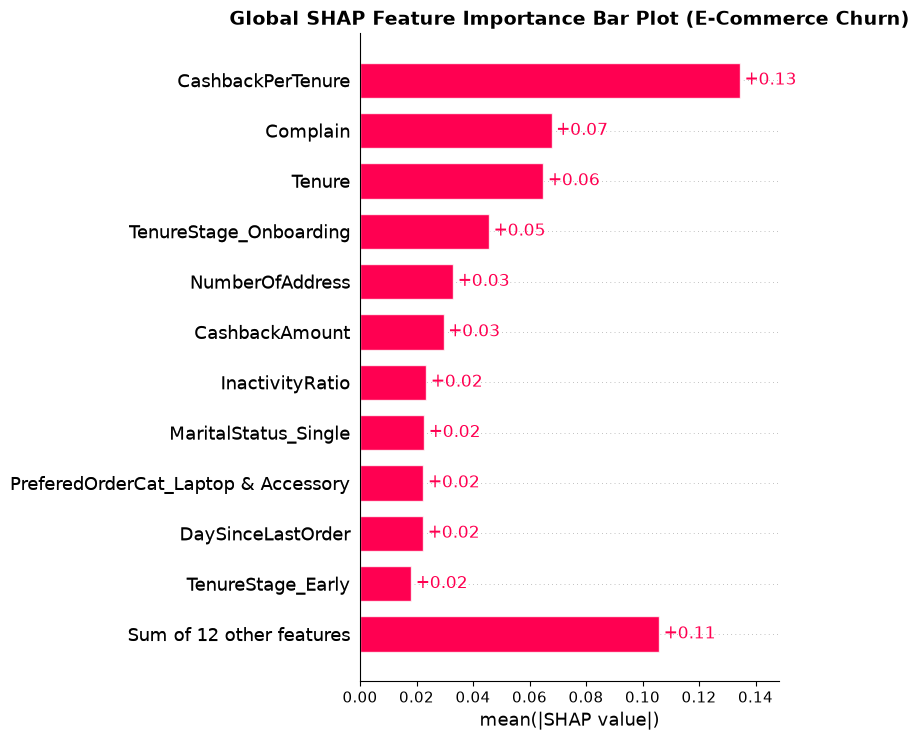

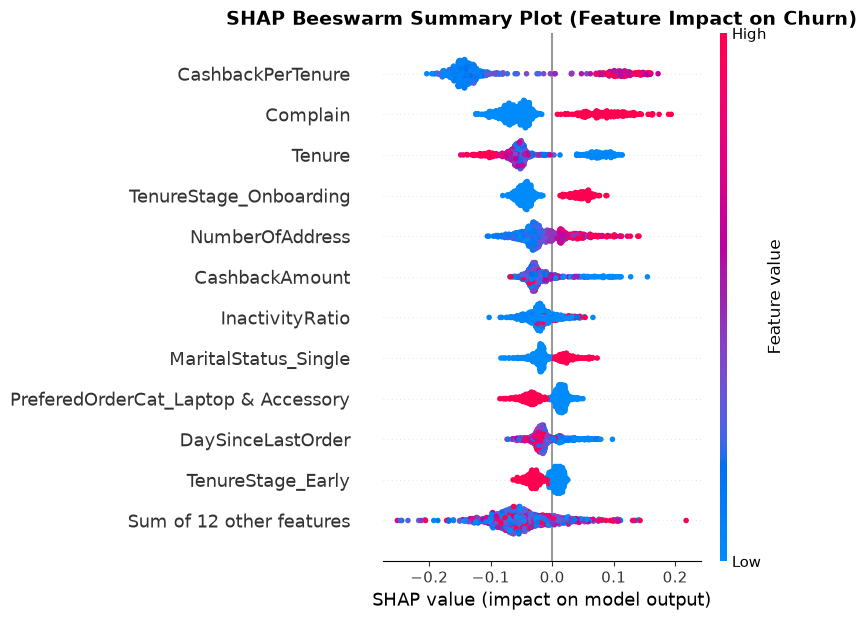

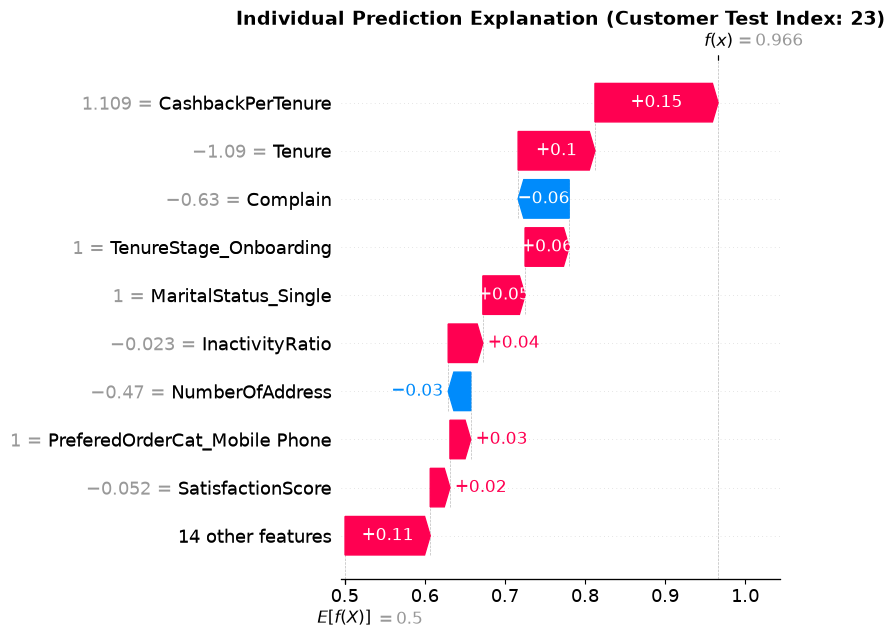


Evaluation graphics successfully saved to models/:
 - models/shap_bar_plot.png
 - models/shap_summary_plot.png
 - models/shap_waterfall_individual.png


In [1]:
# =========================================================
# 05. MODEL SHAP EXPLAINABILITY & EVALUATION
# =========================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.base import BaseEstimator, TransformerMixin

os.makedirs('models', exist_ok=True)

# ---------------------------------------------------------
# 1. DEFINE CUSTOM TRANSFORMER CLASS (REQUIRED FOR UNPICKLING)
# ---------------------------------------------------------
class EcommerceFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Engineers e-commerce domain features from raw input columns.
    Included in namespace for clean joblib unpickling.
    """
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Guard against pre-processed numpy arrays
        if isinstance(X, np.ndarray):
            return X

        X = X.copy()
        if 'PreferedOrderCat' in X.columns:
            X['PreferedOrderCat'] = X['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

        tenure_safe = X['Tenure'].fillna(1.0)
        X['CashbackPerTenure'] = X['CashbackAmount'] / (tenure_safe + 1.0)

        days_since_safe = X['DaySinceLastOrder'].fillna(0.0)
        X['InactivityRatio'] = days_since_safe / (tenure_safe * 30.0 + 1.0)

        X['HighRiskComplain'] = (
            (X['Complain'] == 1) & (X['SatisfactionScore'] <= 2)
        ).astype(int)

        X['TenureStage'] = pd.cut(
            tenure_safe,
            bins=[-np.inf, 3, 12, 24, np.inf],
            labels=['Onboarding', 'Early', 'Established', 'Loyal']
        ).astype(str)

        return X

# ---------------------------------------------------------
# 2. FLEXIBLE ASSET PATH RESOLUTION & DATA UNPICKLING
# ---------------------------------------------------------
model_candidates = ['models/churn_model.joblib', 'churn_model.joblib', '../models/churn_model.joblib']
model_path = next((p for p in model_candidates if os.path.exists(p)), None)

prep_candidates = ['models/preprocessor.joblib', 'preprocessor.joblib', '../models/preprocessor.joblib']
prep_path = next((p for p in prep_candidates if os.path.exists(p)), None)

npz_candidates = ['data/ecom_processed_data.npz', 'ecom_processed_data.npz', '../data/ecom_processed_data.npz']
npz_path = next((p for p in npz_candidates if os.path.exists(p)), None)

if not model_path or not prep_path or not npz_path:
    raise FileNotFoundError("Missing model, preprocessor, or test dataset files.")

model_pipeline = joblib.load(model_path)
preprocessor = joblib.load(prep_path)

data = np.load(npz_path)
X_test, y_test = data['X_test'], data['y_test']

# Extract underlying tree classifier for SHAP TreeExplainer
if hasattr(model_pipeline, 'named_steps') and 'classifier' in model_pipeline.named_steps:
    classifier = model_pipeline.named_steps['classifier']
elif hasattr(model_pipeline, 'predict_proba'):
    classifier = model_pipeline
else:
    raise ValueError("Loaded model object does not contain a valid classifier.")

# ---------------------------------------------------------
# 3. RECOVER EXACT TRANSFORMED FEATURE NAMES
# ---------------------------------------------------------
if hasattr(preprocessor, 'named_steps') and 'preprocessor' in preprocessor.named_steps:
    raw_feature_names = preprocessor.named_steps['preprocessor'].get_feature_names_out()
elif hasattr(preprocessor, 'get_feature_names_out'):
    raw_feature_names = preprocessor.get_feature_names_out()
else:
    raw_feature_names = [f"feature_{i}" for i in range(X_test.shape[1])]

clean_feature_names = [f.split('__')[-1] for f in raw_feature_names]
X_test_df = pd.DataFrame(X_test, columns=clean_feature_names)

print(f"Total features evaluated for SHAP analysis: {len(clean_feature_names)}")

# ---------------------------------------------------------
# 4. COMPUTE SHAP VALUES VIA TREEEXPLAINER
# ---------------------------------------------------------
explainer = shap.TreeExplainer(classifier)
shap_values = explainer(X_test_df)

# Extract positive churn class (Class 1) if multi-dimensional
if len(shap_values.shape) == 3:
    shap_values_churn = shap_values[:, :, 1]
else:
    shap_values_churn = shap_values

# ---------------------------------------------------------
# 5. GLOBAL FEATURE IMPORTANCE (MEAN ABSOLUTE SHAP)
# ---------------------------------------------------------
mean_shap = np.abs(shap_values_churn.values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Mean_|SHAP|_Value': mean_shap
}).sort_values(by='Mean_|SHAP|_Value', ascending=False)

print("\n=== Global SHAP Feature Importance ===")
display(importance_df.head(10))

# ---------------------------------------------------------
# 6. SHAP BAR PLOT
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_churn, max_display=12, show=False)
plt.title("Global SHAP Feature Importance Bar Plot (E-Commerce Churn)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('models/shap_bar_plot.png')
plt.show()

# ---------------------------------------------------------
# 7. SHAP SUMMARY (BEESWARM) PLOT
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_churn, max_display=12, show=False)
plt.title("SHAP Beeswarm Summary Plot (Feature Impact on Churn)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('models/shap_summary_plot.png')
plt.show()

# ---------------------------------------------------------
# 8. INDIVIDUAL PREDICTION WATERFALL EXPLANATION
# ---------------------------------------------------------
y_prob = classifier.predict_proba(X_test)[:, 1]
high_risk_matches = np.where((y_prob > 0.8) & (y_test == 1))[0]
high_risk_idx = high_risk_matches[0] if len(high_risk_matches) > 0 else 0

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values_churn[high_risk_idx], max_display=10, show=False)
plt.title(f"Individual Prediction Explanation (Customer Test Index: {high_risk_idx})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('models/shap_waterfall_individual.png')
plt.show()

print("\nEvaluation graphics successfully saved to models/:")
print(" - models/shap_bar_plot.png")
print(" - models/shap_summary_plot.png")
print(" - models/shap_waterfall_individual.png")